In [166]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.cluster import KMeans
from sklearn.calibration import CalibratedClassifierCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [167]:
# Cell 2: Load the dataset
df = pd.read_excel('combined_finals_with_attendance.xlsx', sheet_name='Sheet1')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (301, 22)


,Has_Failure_Before_Sem5,Internal_Avg_Sem1,Internal_Avg_Sem2,Internal_Avg_Sem3,Internal_Avg_Sem4,Internal_Avg_Sem5,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,...,branch,hosteller,regno,CGPA,Ext_Avg_Sem1,Ext_Avg_Sem2,Ext_Avg_Sem3,Ext_Avg_Sem4,Ext_Avg_Sem5,Absent Percentage (%)
0,0,36.521739,36.68,46.000000,39.000000,47.000000,7.0435,7.56,6.6818,7.6000,...,Chemical Engineering,Day Scholar,127006043,7.42252,66.086957,77.20,68.000000,62.000000,66.000000,15.89
1,1,33.434783,31.96,28.941176,31.882353,31.636364,5.6522,6.00,6.4286,5.0476,...,Chemical Engineering,Hosteler,127002023,5.85296,53.739130,57.84,69.647059,47.764706,60.909091,9.66
2,1,25.521739,24.20,24.647059,31.352941,32.681818,4.1304,4.32,4.0000,4.0000,...,Chemical Engineering,Day Scholar,127002046,4.05372,45.826087,52.64,47.529412,31.882353,34.636364,6.23
3,1,28.608696,31.48,33.235294,33.352941,33.590909,5.4783,6.64,6.5714,5.2381,...,Chemical Engineering,Day Scholar,127002038,6.16738,54.956522,70.16,67.647059,44.588235,71.000000,12.11
4,1,32.434783,29.32,26.411765,34.235294,31.181818,5.8696,5.36,4.9524,6.2857,...,Chemical Engineering,Hosteler,127002055,5.11172,54.956522,55.20,52.117647,59.058824,29.272727,22.49


In [168]:
# Cell 3: Preprocessing
# Drop unnecessary columns
df.drop('regno', axis=1, inplace=True)
df.drop('CGPA', axis=1, inplace=True)
sgpa_cols = [f'SGPA_Sem{i}' for i in range(1,6)]
df.drop(sgpa_cols, axis=1, inplace=True)

# Map hosteller to binary
df['hosteller'] = (df['hosteller'] == 'Hosteler').astype(int)

# One-hot encode admission_category and branch
df = pd.get_dummies(df, columns=['admission_category', 'branch'], drop_first=True)

# Rename target column
df.rename(columns={'Has_Failure_Before_Sem5': 'arrears'}, inplace=True)

# Define risk (External marks in Sem5 < 61)
THRESHOLD = 61
df['risk'] = (df['Ext_Avg_Sem5'] <= THRESHOLD).astype(int)

print("Risk distribution:")
print(df['risk'].value_counts(normalize=True))

# Base numeric features
numeric_cols = [f'Internal_Avg_Sem{i}' for i in range(1,6)] + \
               [f'Ext_Avg_Sem{i}' for i in range(1,5)] + \
               ['arrears', 'hosteller'] + \
               [col for col in df.columns if col.startswith('admission_category_') or col.startswith('branch_')] + \
               ['Absent Percentage (%)']

numeric_cols = [col for col in numeric_cols if col in df.columns]
X_base = df[numeric_cols].copy()
y = df['risk']
print("Initial feature count:", X_base.shape[1])

Risk distribution:
risk
0    0.780731
1    0.219269
Name: proportion, dtype: float64
Initial feature count: 17


In [169]:
# Cell 4: Advanced Feature Engineering
# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_base)
X_base = pd.DataFrame(X_imputed, columns=numeric_cols, index=df.index)

# ---- Trend features (difference) ----
for sem in range(2,6):
    X_base[f'Internal_trend_Sem{sem}'] = X_base[f'Internal_Avg_Sem{sem}'] - X_base[f'Internal_Avg_Sem{sem-1}']
for sem in range(2,5):
    X_base[f'Ext_trend_Sem{sem}'] = X_base[f'Ext_Avg_Sem{sem}'] - X_base[f'Ext_Avg_Sem{sem-1}']

# ---- Gap features (internal - external) ----
for sem in range(1,5):
    X_base[f'Int_Ext_gap_Sem{sem}'] = X_base[f'Internal_Avg_Sem{sem}'] - X_base[f'Ext_Avg_Sem{sem}']

# ---- Rolling statistics (window=2) ----
for sem in range(3,6):
    X_base[f'Internal_roll2_Sem{sem}'] = (X_base[f'Internal_Avg_Sem{sem-1}'] + X_base[f'Internal_Avg_Sem{sem}']) / 2
    X_base[f'Internal_std_Sem{sem-1}_{sem}'] = X_base[[f'Internal_Avg_Sem{sem-1}', f'Internal_Avg_Sem{sem}']].std(axis=1)

# ---- Weighted averages (later semesters get higher weight) ----
weights_int = {1:0.5, 2:0.5, 3:1.5, 4:2.0, 5:2.0}
weights_ext = {1:0.5, 2:0.5, 3:1.5, 4:2.0}

num = den = 0
for sem in range(1,6):
    w = weights_int[sem]
    num += w * X_base[f'Internal_Avg_Sem{sem}']
    den += w
X_base['Weighted_Internal'] = num / den

num = den = 0
for sem in range(1,5):
    w = weights_ext[sem]
    num += w * X_base[f'Ext_Avg_Sem{sem}']
    den += w
X_base['Weighted_External'] = num / den

# ---- Ratio features (Internal / External) ----
for sem in range(1,5):
    X_base[f'Int_Ext_ratio_Sem{sem}'] = X_base[f'Internal_Avg_Sem{sem}'] / (X_base[f'Ext_Avg_Sem{sem}'] + 1e-5)

# ---- Interactions with arrears and absent ----
X_base['arrears_x_Weighted_Internal'] = X_base['arrears'] * X_base['Weighted_Internal']
X_base['arrears_x_Absent'] = X_base['arrears'] * X_base['Absent Percentage (%)']

# ---- Granular bins for Absent Percentage (5% intervals) ----
bins = [0,5,10,15,20,25,100]
labels = [f'absent_{i}_{j}' for i,j in zip(bins[:-1], bins[1:])]
X_base['Absent_Bin'] = pd.cut(X_base['Absent Percentage (%)'], bins=bins, labels=labels)
absent_dummies = pd.get_dummies(X_base['Absent_Bin'], prefix='absent_bin')
X_base = pd.concat([X_base, absent_dummies], axis=1)

for col in absent_dummies.columns:
    X_base[f'{col}_x_Weighted_Internal'] = X_base[col] * X_base['Weighted_Internal']
    X_base[f'{col}_x_Weighted_External'] = X_base[col] * X_base['Weighted_External']

X_base.drop('Absent_Bin', axis=1, inplace=True)

# ---- Clustering of student trajectories (internal marks across semesters) ----
traj_cols = [f'Internal_Avg_Sem{i}' for i in range(1,6)]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
X_base['trajectory_cluster'] = kmeans.fit_predict(X_base[traj_cols])

# ---- Drop constant columns ----
X = X_base.loc[:, X_base.var() > 1e-10]
print("Features after engineering:", X.shape[1])

Features after engineering: 61


In [170]:
# Cell 5: Feature Selection using Recursive Feature Elimination (RFE)
# Keep top 25 features to reduce overfitting
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rfe = RFE(estimator=rf_selector, n_features_to_select=25, step=2)
X_selected = rfe.fit_transform(X, y)
selected_features = X.columns[rfe.support_]
X = pd.DataFrame(X_selected, columns=selected_features, index=X.index)
print("Selected features:", X.shape[1])
print("Features used:", list(X.columns))

Selected features: 25
Features used: ['Internal_Avg_Sem1', 'Internal_Avg_Sem3', 'Internal_Avg_Sem4', 'Internal_Avg_Sem5', 'Ext_Avg_Sem1', 'Ext_Avg_Sem3', 'Ext_Avg_Sem4', 'Internal_trend_Sem2', 'Internal_trend_Sem3', 'Internal_trend_Sem4', 'Internal_trend_Sem5', 'Ext_trend_Sem3', 'Int_Ext_gap_Sem1', 'Int_Ext_gap_Sem2', 'Int_Ext_gap_Sem4', 'Internal_roll2_Sem3', 'Internal_roll2_Sem4', 'Internal_std_Sem3_4', 'Internal_roll2_Sem5', 'Weighted_Internal', 'Weighted_External', 'Int_Ext_ratio_Sem1', 'Int_Ext_ratio_Sem3', 'Int_Ext_ratio_Sem4', 'arrears_x_Weighted_Internal']


In [171]:
# Cell 6: Cross‑validation setup (outer 10‑fold)
cv_outer = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [172]:
# Cell 7: Base learners for stacking and their hyperparameter grids
base_models = {
    'lr': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'rf': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'xgb': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                              scale_pos_weight=(len(y)-sum(y))/sum(y)),
    'lgb': lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
}

param_grids = {
    'lr': {'classifier__C': [0.01, 0.1, 1, 10, 100]},
    'rf': {'classifier__n_estimators': [100, 300, 500],
           'classifier__max_depth': [5, 10, None],
           'classifier__min_samples_split': [2, 5, 10]},
    'xgb': {'classifier__learning_rate': [0.01, 0.05, 0.1, 0.3],
            'classifier__max_depth': [3, 5, 7],
            'classifier__subsample': [0.7, 0.8, 1.0],
            'classifier__colsample_bytree': [0.7, 0.8, 1.0]},
    'lgb': {'classifier__num_leaves': [31, 50, 70],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__n_estimators': [100, 300]}
}

In [173]:
# Cell 8: Hyperparameter tuning for each base model using RandomizedSearchCV
best_estimators = {}

for name, model in base_models.items():
    print(f"\nTuning {name}...")
    pipeline = ImbPipeline([
        ('smoteenn', SMOTEENN(random_state=42)),   # SMOTE + Edited Nearest Neighbours
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(pipeline, param_grids[name], cv=inner_cv,
                                scoring='f1', n_iter=20, random_state=42, n_jobs=-1)
    search.fit(X, y)
    best_estimators[name] = search.best_estimator_
    print(f"Best {name} CV F1: {search.best_score_:.4f}")


Tuning lr...
Best lr CV F1: 0.7668

Tuning rf...
Best rf CV F1: 0.7547

Tuning xgb...
Best xgb CV F1: 0.7506

Tuning lgb...
Best lgb CV F1: 0.7660


In [174]:
# Cell 9: Stacking ensemble with meta‑learner (XGBoost) and probability calibration
meta_xgb = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                             use_label_encoder=False, eval_metric='logloss',
                             random_state=42, scale_pos_weight=(len(y)-sum(y))/sum(y))
meta_pipeline = Pipeline([('scaler', StandardScaler()), ('clf', meta_xgb)])

stacking_clf = StackingClassifier(
    estimators=[(name, best_estimators[name]) for name in base_models.keys()],
    final_estimator=meta_pipeline,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

# Calibrate probabilities for better threshold tuning
calibrated_stacking = CalibratedClassifierCV(stacking_clf, method='sigmoid', cv=3)

In [175]:
# Cell 10: Evaluate stacking using 10‑fold CV with per‑fold threshold tuning for F1
thresholds = np.arange(0.1, 0.9, 0.01)
y_proba_all = np.zeros(len(y))
y_pred_all = np.zeros(len(y))
best_thresholds = []

for train_idx, val_idx in cv_outer.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Train stacking without calibration inside the loop to avoid data leakage
    stacking_temp = StackingClassifier(
        estimators=[(name, best_estimators[name]) for name in base_models.keys()],
        final_estimator=meta_pipeline,
        cv=5,
        stack_method='predict_proba',
        n_jobs=-1
    )
    stacking_temp.fit(X_train, y_train)
    proba_val = stacking_temp.predict_proba(X_val)[:,1]

    # Find threshold that maximizes F1 on validation fold
    best_f1 = 0
    best_thresh = 0.5
    for thresh in thresholds:
        pred_thresh = (proba_val >= thresh).astype(int)
        f1_val = f1_score(y_val, pred_thresh)
        if f1_val > best_f1:
            best_f1 = f1_val
            best_thresh = thresh

    y_proba_all[val_idx] = proba_val
    y_pred_all[val_idx] = (proba_val >= best_thresh).astype(int)
    best_thresholds.append(best_thresh)

# Final metrics
final_acc = accuracy_score(y, y_pred_all)
final_f1 = f1_score(y, y_pred_all)
final_auc = roc_auc_score(y, y_proba_all)

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Accuracy: {final_acc:.4f}")
print(f"F1 Score: {final_f1:.4f}")
print(f"AUC: {final_auc:.4f}")
print(f"Mean optimal threshold: {np.mean(best_thresholds):.2f}")


FINAL RESULTS
Accuracy: 0.9302
F1 Score: 0.8511
AUC: 0.9466
Mean optimal threshold: 0.38


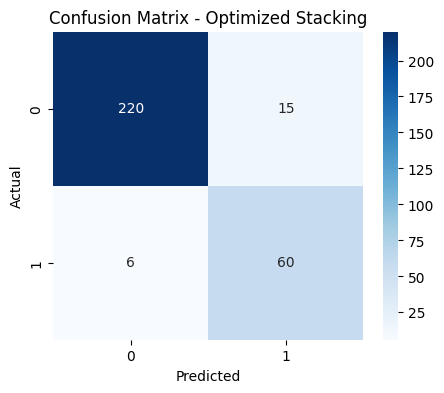

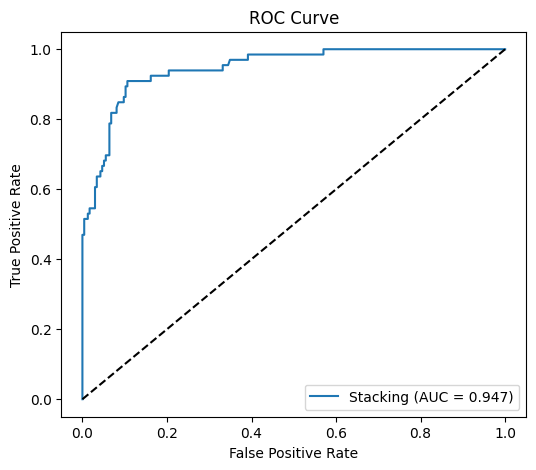

In [176]:
# Cell 11: Confusion Matrix and ROC Curve
cm = confusion_matrix(y, y_pred_all)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Optimized Stacking')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

fpr, tpr, _ = roc_curve(y, y_proba_all)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Stacking (AUC = {final_auc:.3f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

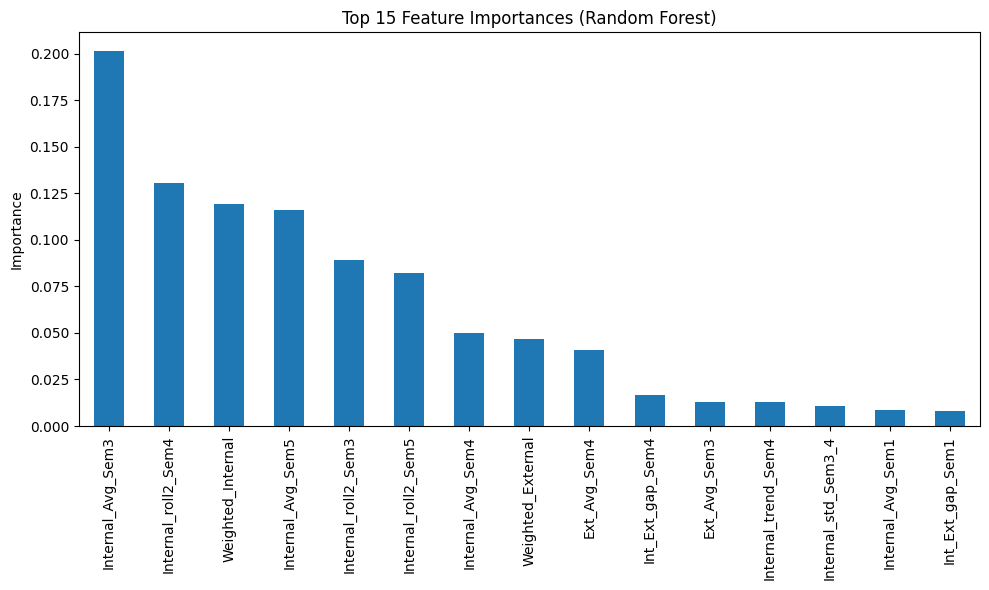

In [177]:
# Cell 12: Feature importance from the tuned Random Forest
rf_best = best_estimators['rf'].named_steps['classifier']
importances = rf_best.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='bar')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [178]:
# Cell 13: Summary of enhancements and results
print("\n" + "="*60)
print("SUMMARY OF ENHANCEMENTS")
print("="*60)
print(f"Risk threshold: Ext_Avg_Sem5 < {THRESHOLD}")
print(f"Final feature count: {X.shape[1]} (selected from {X_base.shape[1]})")
print(f"Dataset size: {X.shape[0]} samples")
print(f"Best F1 Score: {final_f1:.4f}")
print(f"Best Accuracy: {final_acc:.4f}")
print(f"Mean threshold: {np.mean(best_thresholds):.2f}")


SUMMARY OF ENHANCEMENTS
Risk threshold: Ext_Avg_Sem5 < 61
Final feature count: 25 (selected from 61)
Dataset size: 301 samples
Best F1 Score: 0.8511
Best Accuracy: 0.9302
Mean threshold: 0.38


In [179]:
# Save necessary fitted objects and feature names for future use
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import joblib

# Original numeric columns (before feature engineering)
original_numeric_cols = [f'Internal_Avg_Sem{i}' for i in range(1,6)] + \
                        [f'Ext_Avg_Sem{i}' for i in range(1,5)] + ['arrears']

# Re‑fit imputer on the original numeric columns only
imputer_final = SimpleImputer(strategy='median').fit(df[original_numeric_cols])

# scaler_final was fit on X (engineered and selected) - that's fine
scaler_final = StandardScaler().fit(X)

# Extract the Random Forest model from best_estimators (key 'rf')
rf_model = best_estimators['rf'].named_steps['classifier']

# Store the list of final feature columns (X.columns)
feature_names = X.columns.tolist()

# Save the kmeans model from Cell 4 (used for clustering)
kmeans_model = kmeans  # from Cell 4

# Save all objects to disk
joblib.dump(rf_model, 'risk_rf_model.pkl')
joblib.dump(imputer_final, 'imputer.pkl')
joblib.dump(scaler_final, 'scaler.pkl')
joblib.dump(feature_names, 'feature_names.pkl')
joblib.dump(original_numeric_cols, 'original_numeric_cols.pkl')
joblib.dump(kmeans_model, 'kmeans_model.pkl')   # <-- save kmeans for clustering

print("Preprocessing objects, Random Forest, and kmeans model saved.")

Preprocessing objects, Random Forest, and kmeans model saved.


In [ ]:
# Install required libraries
!pip install openai -q
!pip install pdfplumber -q

import pdfplumber
import json
import re
import pandas as pd
import numpy as np
from openai import OpenAI

# ============================================================
# Step 1: Extract syllabus text (truncated to fit token limits)
# ============================================================
pdf_path = "B.Tech. CSE 180 - Scheme and Syllabus - 2021-22 onwards.pdf"
syllabus_text = ""
try:
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if text:
                syllabus_text += text + "\n"
    print("PDF extracted successfully.")
except Exception as e:
    print(f"PDF extraction failed: {e}")

max_chars = 15000
if len(syllabus_text) > max_chars:
    syllabus_text = syllabus_text[:max_chars]
    print(f"Truncated syllabus to {max_chars} characters.")

# ============================================================
# Static prerequisite map (provided by user)
# ============================================================
static_prerequisite_map = {
    "THEORY OF COMPUTATION": ["DISCRETE STRUCTURES", "ENGINEERING MATHEMATICS – III"],
    "OPERATING SYSTEMS": ["COMPUTER ORGANIZATION", "DATA STRUCTURES"],
    "COMPUTER NETWORKS": ["COMPUTER ORGANIZATION"],
    "SOFT SKILLS - I": [],
    "STATISTICAL FOUNDATIONS FOR COMPUTER SCIENCE": ["ENGINEERING MATHEMATICS – III"],
    "NETWORK TOOLS & TECHNIQUES": ["COMPUTER NETWORKS"],
    "ARTIFICIAL INTELLIGENCE": ["DATA STRUCTURES", "DISCRETE STRUCTURES"],
    "PYTHON PROGRAMMING WITH WEB FRAMEWORKS": ["PROBLEM SOLVING & PROGRAMMING IN C"],
    "LINUX PROGRAMMING": [],
    "DIGITAL IMAGE PROCESSING": ["ENGINEERING MATHEMATICS – III", "DATA STRUCTURES"],
    "SYSTEM SOFTWARE": ["COMPUTER ORGANIZATION"],
    "SYSTEM MODELLING & SIMULATION": ["ENGINEERING MATHEMATICS – III"],
    "SCRIPT PROGRAMMING": ["PROBLEM SOLVING & PROGRAMMING IN C"],
}

# ============================================================
# Load the semester-wise subjects file
# ============================================================
df_semester = pd.read_excel('semester_wise_subjects_final.xlsx')

# ============================================================
# Grade to point mapping
# ============================================================
grade_to_point = {'S':10, 'A+':9, 'A':8, 'B':7, 'C':6, 'D':5, 'E':4, 'F':0}

# ============================================================
# LLM setup (GitHub Models)
# ============================================================
#GITHUB_TOKEN = "github_pat_dummy"  # Replace with your actual token
#client = OpenAI(base_url="https://models.inference.ai.azure.com", api_key=GITHUB_TOKEN)

# Cache for topics to avoid repeated API calls
topics_cache = {}

def get_topics_from_llm(subject, syllabus_text):
    """Extract key topics for a subject using LLM."""
    if subject in topics_cache:
        return topics_cache[subject]
    prompt = f"""You are a syllabus expert. For the course "{subject}", list the main topics (3-8 key topics) that are essential for understanding the subject. Output ONLY a JSON list of strings. Do not include any extra text. Example: ["Topic1", "Topic2", ...]

Syllabus text (for reference):
{syllabus_text}
"""
    try:
        response = client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model="gpt-4o",
            temperature=0.4,
            max_tokens=300
        )
        output = response.choices[0].message.content
        json_match = re.search(r'\[.*\]', output, re.DOTALL)
        if json_match:
            topics = json.loads(json_match.group(0))
            topics_cache[subject] = topics
            return topics
        else:
            topics_cache[subject] = []
            return []
    except Exception as e:
        print(f"LLM topic extraction failed for {subject}: {e}")
        topics_cache[subject] = []
        return []

# ============================================================
# Helper functions for grade parsing and analysis
# ============================================================
def normalize_course_name(name):
    if pd.isna(name): return ''
    name = str(name).upper().strip()
    name = re.sub(r'[–—]', '-', name)
    name = ' '.join(name.split())
    return name

def compute_grade_point(grade_str):
    if pd.isna(grade_str): return 0
    return grade_to_point.get(str(grade_str).strip().upper(), 0)

def parse_semester_subjects(sem_str):
    if pd.isna(sem_str) or sem_str == '': return {}
    items = sem_str.split(';')
    res = {}
    for item in items:
        if ':' in item:
            course, grade = item.split(':',1)
            course = normalize_course_name(course)
            res[course] = compute_grade_point(grade.strip())
    return res

def parse_semester_5_courses(sem5_str):
    if pd.isna(sem5_str) or sem5_str == '': return []
    items = sem5_str.split(';')
    res = []
    for item in items:
        if ':' in item:
            course = item.split(':',1)[0].strip()
        else:
            course = item.strip()
        res.append(normalize_course_name(course))
    return res

def get_student_data(regno):
    student_row = df_semester[df_semester['regno'].astype(str) == str(regno)]
    if student_row.empty:
        return None, None, None, None, None
    grade_dict = {}
    sem_dict = {}
    all_points = []
    semester_grades = {1: [], 2: [], 3: [], 4: []}
    for sem in range(1,5):
        col = f'Semester_{sem}_Subjects'
        if col in student_row.columns:
            data = parse_semester_subjects(student_row.iloc[0][col])
            for c, pt in data.items():
                grade_dict[c] = pt
                sem_dict[c] = sem
                all_points.append(pt)
                semester_grades[sem].append((c, pt))
    avg_point = np.mean(all_points) if all_points else 0
    sem5_str = student_row.iloc[0].get('Semester_5_Subjects', '')
    sem5_courses = parse_semester_5_courses(sem5_str)
    return grade_dict, sem_dict, avg_point, semester_grades, sem5_courses

# ============================================================
# Rule‑based fallback report (narrative)
# ============================================================
def generate_rule_based_report(regno, avg_point, weak_subjects, weak_prereqs, prob_risk):
    risk_level = "HIGH" if prob_risk >= 0.5 else "LOW"
    lines = []
    lines.append("=" * 70)
    lines.append(f"ACADEMIC REPORT FOR STUDENT {regno} (Rule‑Based)")
    lines.append("=" * 70)
    lines.append(f"\n📊 Model Risk Probability: {prob_risk:.2%} ({risk_level} risk)")
    lines.append(f"📈 Overall Average Grade Point (Semesters 1-4): {avg_point:.2f}")
    if weak_subjects:
        lines.append("\n⚠️ WEAK SUBJECTS (Grade D/E/F):")
        for course, pt in weak_subjects:
            lines.append(f"   • {course} (point {pt})")
    if weak_prereqs:
        lines.append("\n🔸 PREREQUISITE WEAKNESSES AFFECTING SEMESTER 5:")
        for course, prereq, pt, sem in weak_prereqs:
            lines.append(f"   • {course} requires {prereq} (Sem {sem}, point {pt}) – below average/weak.")
    else:
        lines.append("\n✅ No critical prerequisite weaknesses detected.")
    lines.append("\n📌 RECOMMENDATIONS:")
    lines.append("   • Review weak subjects and prerequisite topics before focusing on current courses.")
    lines.append("   • Seek extra help or tutoring for foundational gaps.")
    lines.append("   • Use past exam papers and mock tests to improve.")
    lines.append("=" * 70)
    return "\n".join(lines)

# ============================================================
# Main combined report function
# ============================================================
def generate_combined_report(student_raw_df):
    regno = student_raw_df.iloc[0]['regno']

    # Get student grade data
    grade_dict, sem_dict, avg_point, semester_grades, sem5_courses = get_student_data(regno)
    if grade_dict is None:
        return f"Student {regno} not found in semester file."

    # Weak subjects (absolute point < 6)
    weak_subjects = [(c, pt) for c, pt in grade_dict.items() if pt < 6]

    # For each semester 5 course, list weak prerequisites (below average)
    course_weak_prereqs = {}
    for course in sem5_courses:
        prereqs = static_prerequisite_map.get(course, [])
        weak_for_course = []
        for prereq in prereqs:
            prereq_norm = normalize_course_name(prereq)
            if prereq_norm in grade_dict and grade_dict[prereq_norm] < avg_point:
                weak_for_course.append((prereq_norm, grade_dict[prereq_norm], sem_dict.get(prereq_norm, '?')))
        course_weak_prereqs[course] = weak_for_course

    # All prerequisite subjects for semester 5 (for the comparison table)
    all_prereqs = set()
    for course in sem5_courses:
        for prereq in static_prerequisite_map.get(course, []):
            all_prereqs.add(normalize_course_name(prereq))

    # ----- Part 1: LLM Narrative Report -----
    try:
        # Preprocess raw student data for ML model
        student_clean = preprocess_raw_student(student_raw_df)
        X_student = engineer_features(student_clean)
        X_student_scaled = scaler_final.transform(X_student)
        prob_risk = rf_model.predict_proba(X_student_scaled)[0, 1]
        risk_level = "HIGH" if prob_risk >= 0.5 else "LOW"

        importances = rf_model.feature_importances_
        X_train_means = X.mean().values
        student_values = X_student.values[0]
        X_train_std = X.std().values
        z_scores = (student_values - X_train_means) / (X_train_std + 1e-8)
        feat_impact = pd.DataFrame({
            'feature': feature_names,
            'importance': importances,
            'z_score': z_scores,
            'student_value': student_values,
            'mean': X_train_means
        })
        feat_impact = feat_impact[feat_impact['importance'] > 0.01].copy()
        feat_impact['abs_z'] = np.abs(feat_impact['z_score'])
        feat_impact = feat_impact.sort_values('abs_z', ascending=False).head(10)

        prompt = f"""You are an academic advisor. A student has the following academic profile (based on internal and external exam marks from Semesters 1-4, and internal marks of Semester 5). The model predicts a {risk_level} risk (probability {prob_risk:.2%}) of failing the Semester 5 external exams (threshold: <73 marks).

Key deviations from the average student (positive z-score means higher than average, negative means lower):

"""
        for _, row in feat_impact.iterrows():
            prompt += f"- {row['feature']}: student = {row['student_value']:.2f}, mean = {row['mean']:.2f}, z-score = {row['z_score']:.2f}\n"
        prompt += f"\nThe student's overall average grade point from Semesters 1-4 is {avg_point:.2f}.\n"
        if weak_subjects:
            prompt += "\nThe student has weak performance (grade D, E, or F) in the following subjects from previous semesters:\n"
            for course, pt in weak_subjects:
                prompt += f"- {course} (grade point {pt})\n"
            prompt += "These subjects need focused revision.\n"
        else:
            prompt += "\nNo weak subjects (below C grade) found in previous semesters.\n"
        if any(course_weak_prereqs.values()):
            prompt += "\nAdditionally, the following prerequisite weaknesses for Semester 5 courses were identified (prerequisite grade point below student's average):\n"
            for course, weak_list in course_weak_prereqs.items():
                if weak_list:
                    for prereq, pt, sem in weak_list:
                        prompt += f"- {course} requires {prereq} (taken in semester {sem}) with grade point {pt}, which is below the student's average.\n"
        else:
            prompt += "\nNo prerequisite weaknesses relative to the student's average.\n"
        prompt += """
Based on all the above information, please provide:
1. A clear assessment of the student's strengths and weaknesses.
2. Specific, actionable recommendations to improve performance in Semester 5. Emphasize revising the weak subjects (especially those with D/F grades) and prerequisite gaps.
3. Encouraging tone but honest about risks.

Keep the report concise (max 400 words) and formatted for easy reading.
"""
        response = client.chat.completions.create(
            messages=[
                {"role": "system", "content": "You are a helpful academic advisor with expertise in curriculum prerequisites and student weaknesses."},
                {"role": "user", "content": prompt}
            ],
            model="gpt-4o",
            temperature=0.7,
            max_tokens=700
        )
        narrative = response.choices[0].message.content
    except Exception as e:
        # Fallback to rule-based if ML or API fails
        prob_risk = 0.5  # dummy
        weak_prereqs_flat = [(c, p, pt, s) for c, lst in course_weak_prereqs.items() for p, pt, s in lst]
        narrative = generate_rule_based_report(regno, avg_point, weak_subjects, weak_prereqs_flat, prob_risk)

    # ----- Part 2: Subject‑wise detailed analysis -----
    lines = []
    lines.append("\n" + "=" * 80)
    lines.append("📚 SUBJECT‑WISE DETAILED ANALYSIS")
    lines.append("=" * 80)
    lines.append(f"\n📈 Overall Average Grade Point (Semesters 1-4): {avg_point:.2f}")

    # All subjects with grade points (by semester)
    lines.append("\n📚 ALL SUBJECTS AND GRADE POINTS (Semesters 1-4):")
    for sem in range(1,5):
        lines.append(f"\n   Semester {sem}:")
        if semester_grades[sem]:
            for course, pt in sorted(semester_grades[sem]):
                lines.append(f"      • {course}: {pt}")
        else:
            lines.append("      • (No subjects found)")

    # Weak subjects (absolute)
    if weak_subjects:
        lines.append("\n⚠️ WEAK SUBJECTS (Grade D/E/F) – Absolute Weakness:")
        for course, pt in weak_subjects:
            lines.append(f"   • {course} (point {pt})")
    else:
        lines.append("\n✅ No absolute weak subjects (grade D/E/F).")

    # Prerequisite subjects with comparison to average (overview table)
    if all_prereqs:
        lines.append("\n🔍 PREREQUISITE SUBJECTS FOR SEMESTER 5 COURSES (overview):")
        for prereq in sorted(all_prereqs):
            if prereq in grade_dict:
                pt = grade_dict[prereq]
                sem = sem_dict.get(prereq, '?')
                if pt < avg_point:
                    lines.append(f"   ⚠️ {prereq} (Sem {sem}) – grade point = {pt} (BELOW average {avg_point:.2f})")
                else:
                    lines.append(f"   ✅ {prereq} (Sem {sem}) – grade point = {pt} (at or above average)")
            else:
                lines.append(f"   ❓ {prereq} – NOT FOUND in student's records")
    else:
        lines.append("\n🔍 No prerequisites defined for semester 5 courses.")

    # Detailed topics for each semester 5 course and its weak prerequisites
    lines.append("\n🔸 DETAILED TOPICS FOR WEAK PREREQUISITES (By Semester 5 Course):")
    has_weak = False
    for course in sem5_courses:
        weak_list = course_weak_prereqs.get(course, [])
        if weak_list:
            has_weak = True
            lines.append(f"\n📘 {course}")
            for prereq, pt, sem in weak_list:
                lines.append(f"   ⚠️ Requires {prereq} (Semester {sem}, grade point = {pt})")
                topics = get_topics_from_llm(prereq, syllabus_text)
                if topics:
                    lines.append("      Topics to revise:")
                    for topic in topics[:6]:
                        lines.append(f"         • {topic}")
                else:
                    lines.append("      (No specific topics extracted – review entire subject)")
    if not has_weak:
        lines.append("\n✅ No prerequisite weaknesses relative to student's average.")

    lines.append("\n" + "=" * 80)
    subject_wise = "\n".join(lines)

    # Combine both reports
    final_report = narrative + "\n\n" + subject_wise
    return final_report

# ============================================================
# Example usage
# ============================================================
new_student = pd.DataFrame([{
    'Has_Failure_Before_Sem5': 0,
    'Internal_Avg_Sem1': 42.5, 'Internal_Avg_Sem2': 40.2, 'Internal_Avg_Sem3': 35.1, 'Internal_Avg_Sem4': 33.8, 'Internal_Avg_Sem5': 31.5,
    'Ext_Avg_Sem1': 65.0, 'Ext_Avg_Sem2': 58.0, 'Ext_Avg_Sem3': 52.0, 'Ext_Avg_Sem4': 48.0,
    'hosteller': 'Day Scholar', 'admission_category': 'SASTRA-General', 'branch': 'Computer Science & Engineering',
    'regno': '127003194', 'CGPA': 5.5,
    'SGPA_Sem1': 6.0, 'SGPA_Sem2': 5.8, 'SGPA_Sem3': 5.5, 'SGPA_Sem4': 5.2, 'SGPA_Sem5': 5.0
}])

report = generate_combined_report(new_student)
print(report)

PDF extracted successfully.
Truncated syllabus to 15000 characters.
ACADEMIC REPORT FOR STUDENT 127003194 (Rule‑Based)

📊 Model Risk Probability: 50.00% (HIGH risk)
📈 Overall Average Grade Point (Semesters 1-4): 4.41

⚠️ WEAK SUBJECTS (Grade D/E/F):
   • ENGINEERING MECHANICS (point 0)
   • BASIC ELECTRICAL ENGINEERING (point 5)
   • ENGINEERING PHYSICS (point 0)
   • ENGINEERING CHEMISTRY (point 5)
   • BASIC MECHANICAL ENGINEERING (point 5)
   • BASIC ELECTRONICS ENGINEERING (point 5)
   • COMPUTER ORGANIZATION (point 0)
   • DIGITAL SYSTEM DESIGN LABORATORY (point 5)
   • ENGINEERING MATHEMATICS - III (point 5)
   • DISCRETE STRUCTURES (point 0)
   • FUNDAMENTALS OF DATABASE MANAGEMENT SYSTEMS (point 0)
   • DESIGN & ANALYSIS OF ALGORITHMS (point 0)
   • COMPUTER ARCHITECTURE (point 0)

🔸 PREREQUISITE WEAKNESSES AFFECTING SEMESTER 5:
   • THEORY OF COMPUTATION requires DISCRETE STRUCTURES (Sem 4, point 0) – below average/weak.
   • OPERATING SYSTEMS requires COMPUTER ORGANIZATION (S